**Air pollution is one of the most **dangerous forms of pollution, posing serious risks to human health and the environment. Predicting air quality is essential for protecting public well-being and maintaining a sustainable ecosystem.

With the help of advanced technologies like neural networks, we can better understand pollution patterns and make accurate predictions. Neural networks play a key role in environmental science due to their ability to:

Recognize Patterns: Identify complex relationships in air quality data for accurate predictions.
Adapt Quickly: Learn from data and improve performance over time, similar to the human brain.

By collecting relevant environmental data and applying neural network models, we can efficiently predict air quality and take proactive steps to reduce pollution and protect our planet.

In [3]:
import pandas as pd

data = pd.read_csv("/content/sample_data/city_day.csv")
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
# Checking for missing values
data.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [5]:
data.dropna(axis=0, inplace=True)

In [6]:
import plotly.express as px

# Converting 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# AQI Trend Over Time
fig1 = px.line(data, x='Date', y='AQI', color='City', title='AQI Trend Over Time')
fig1.show()

# AQI Distribution by City
fig2 = px.box(data, x='City', y='AQI', title='AQI Distribution by City')
fig2.update_layout(xaxis={'categoryorder':'total descending'})
fig2.show()

# Scatter Plot Matrix for selected features
selected_features = ['PM2.5', 'NO2', 'CO', 'O3', 'AQI']
fig3 = px.scatter_matrix(data[selected_features], title='Scatter Plot Matrix')
fig3.show()

In [8]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_columns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
# Splitting the dataset into features (X) and target (y)
X = data[feature_columns]
y = data['AQI']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Defining and compiling the neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Training the model
history = model.fit(X_train_scaled, y_train, epochs=150, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 25624.7188 - val_loss: 18924.7324
Epoch 2/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8972.1807 - val_loss: 4641.1523
Epoch 3/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3549.4050 - val_loss: 3041.2000
Epoch 4/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2390.7659 - val_loss: 2011.3759
Epoch 5/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1709.4849 - val_loss: 1445.0994
Epoch 6/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1363.3951 - val_loss: 1157.9828
Epoch 7/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1178.4187 - val_loss: 1006.8081
Epoch 8/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1070.3306 - val_loss: 923.5765
Epoch 9/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1003.1005 - val_loss: 868.8392
Epoch 10/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 952.1052 - val_loss: 845.3799
Epoch 11/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 918.7612 

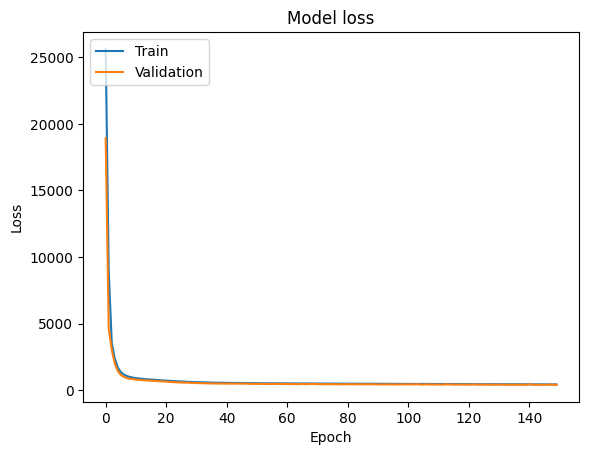

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 446.0076
Mean Squared Error on Test Data: 446.007568359375


In [10]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
loss = model.evaluate(X_test_scaled, y_test)
print("Mean Squared Error on Test Data:", loss)

In [11]:
model.save('model.h5')
user_input = pd.DataFrame({
    'PM2.5': [81],
    'PM10': [124],
    'NO': [1.44],
    'NO2': [20],
    'NOx': [12],
    'NH3': [10],
    'CO': [0.1],
    'SO2': [15],
    'O3': [127],
    'Benzene': [0.20],
    'Toluene': [6],
    'Xylene': [0.06]
})

user_input_scaled = scaler.transform(user_input)

user_pred = model.predict(user_input_scaled)

print(f"Predicted AQI: {user_pred[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted AQI: 199.1107177734375
